# 项目：用线性回归预测房价数据

## 分析目标

此数据分析报告的目的是，基于已有的房屋销售价格，以及有关该房屋的属性，进行线性回归分析，从而利用得到的线性回归模型，能对以下未知售价的房屋根据属性进行价格预测：

面积为6500平方英尺，有4个卧室、2个厕所，总共2层，不位于主路，无客人房，带地下室，有热水器，没有空调，车位数为2，位于城市首选社区，简装修。

## 简介

数据集`house_price.csv`记录了超过五百栋房屋的交易价格，以及房屋的相关属性信息，包括房屋面积、卧室数、厕所数、楼层数、是否位于主路、是否有客房，等等。

`house_price.csv`每列的含义如下：
- price：房屋出售价格
- area：房屋面积，以平方英尺为单位
- bedrooms：卧室数
- bathrooms：厕所数
- stories：楼层数
- mainroad：是否位于主路
   - yes  是
   - no	  否
- guestroom：是否有客房
   - yes  是
   - no	  否
- basement：是否有地下室
   - yes  是
   - no	  否
- hotwaterheating：是否有热水器
   - yes  是
   - no	  否
- airconditioning：是否有空调
   - yes  是
   - no	  否
- parking：车库容量，以车辆数量为单位
- prefarea：是否位于城市首选社区
   - yes  是
   - no	  否
- furnishingstatus：装修状态
   - furnished       精装
   - semi-furnished	 简装
   - unfurnished     毛坯

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
house_price_origin = pd.read_csv('house_price.csv')
house_price_origin

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


## 数据检查

In [3]:
house_price_origin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
house_price_origin.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


## 数据探索

In [5]:
house_price_origin

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


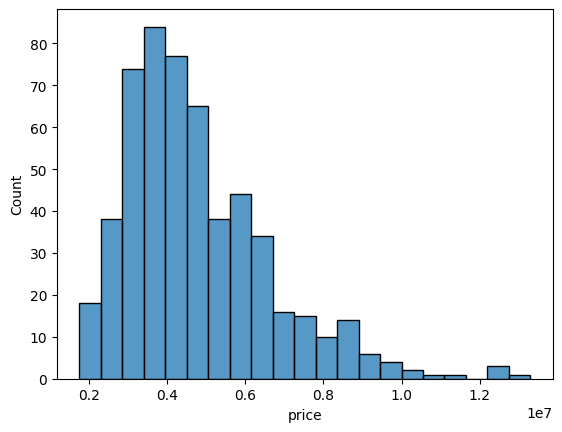

In [6]:
sns.histplot(house_price_origin['price'])
plt.show()

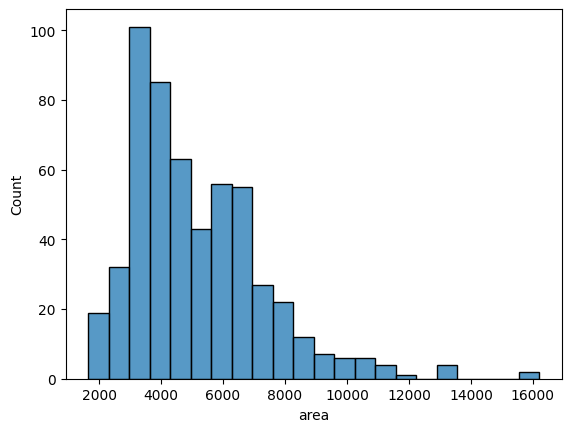

In [7]:
sns.histplot(house_price_origin['area'])
plt.show()

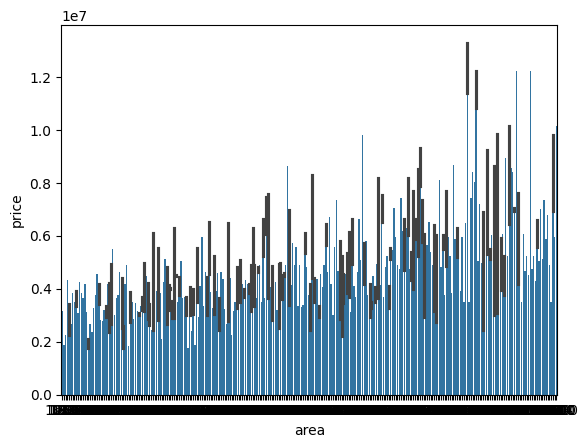

In [8]:
sns.barplot(data=house_price_origin, x='area', y='price')
plt.show()

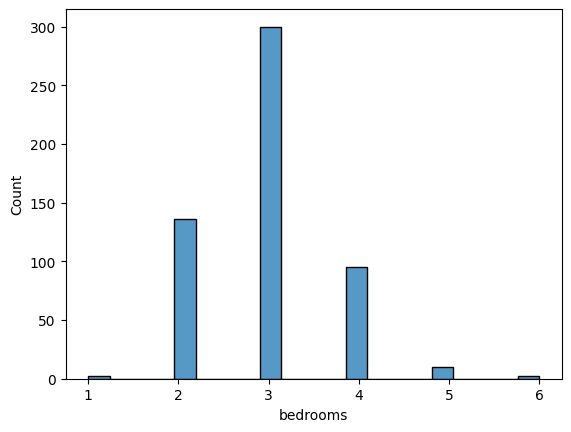

In [9]:
sns.histplot(house_price_origin['bedrooms'])
plt.show()

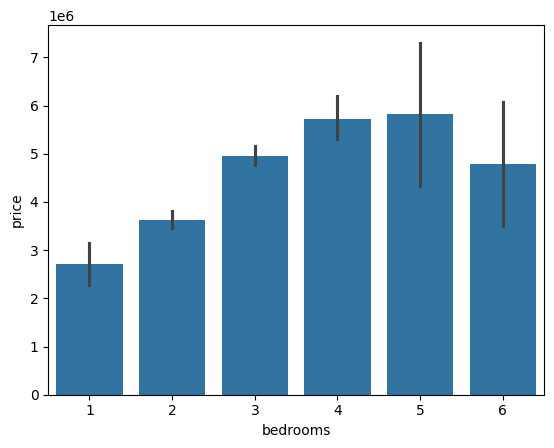

In [10]:
sns.barplot(house_price_origin, x='bedrooms', y='price')
plt.show()

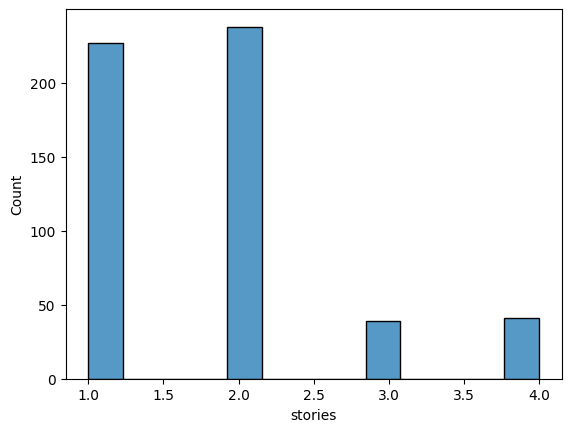

In [11]:
sns.histplot(house_price_origin['stories'])
plt.show()

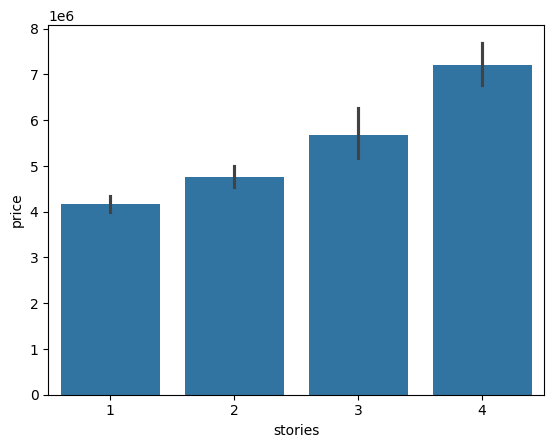

In [12]:
sns.barplot(house_price_origin, x='stories', y='price')
plt.show()

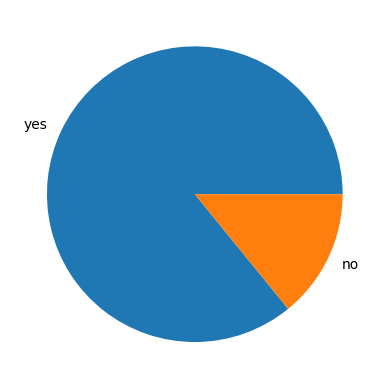

In [13]:
mainroad = pd.DataFrame(house_price_origin['mainroad'].value_counts())
mainroad
plt.pie(mainroad['count'],labels=mainroad.index)
plt.show()

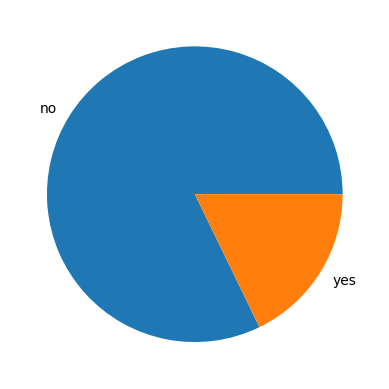

In [14]:
guestroom = pd.DataFrame(house_price_origin['guestroom'].value_counts())
guestroom
plt.pie(guestroom['count'],labels=guestroom.index)
plt.show()

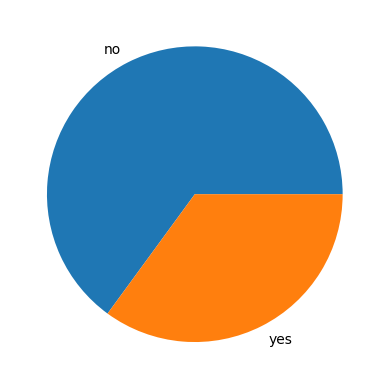

In [15]:
basement = pd.DataFrame(house_price_origin['basement'].value_counts())
basement
plt.pie(basement['count'],labels=basement.index)
plt.show()

In [16]:
house_price_origin['furnishingstatus'].value_counts()

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64

In [17]:
house_price_origin

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


## 数据处理

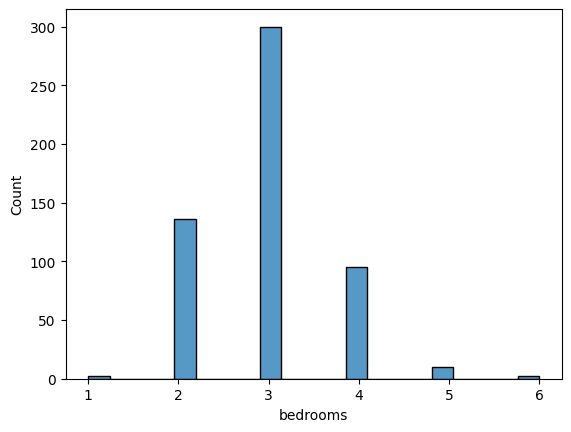

In [18]:
sns.histplot(house_price_origin['bedrooms'])
plt.show()

In [30]:
houseprice_clean = pd.get_dummies(house_price_origin, columns=['furnishingstatus'], drop_first=True, dtype=int).copy().replace({'no':0, 'yes':1})
houseprice_clean

C:\Users\username\AppData\Local\Temp\ipykernel_20824\3216291196.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  houseprice_clean = pd.get_dummies(house_price_origin, columns=['furnishingstatus'], drop_first=True, dtype=int).copy().replace({'no':0, 'yes':1})


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


In [21]:
y = houseprice_clean['price']

In [22]:
X = houseprice_clean.loc[:,'area':'furnishingstatus_unfurnished']

In [23]:
X = sm.add_constant(X)

In [24]:
result = sm.OLS(y, X).fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.674
Method:                 Least Squares   F-statistic:                     87.52
Date:                Mon, 09 Feb 2026   Prob (F-statistic):          9.07e-123
Time:                        10:35:22   Log-Likelihood:                -8331.5
No. Observations:                 545   AIC:                         1.669e+04
Df Residuals:                     531   BIC:                         1.675e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
===================================================================================================
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                            4.277e+04   2.64e+05      0.162      0.872   -4.76e+05    5.62e+05
area                              244.1394     24.289     10.052      0.000     196.425     291.853
bedrooms                         1.148e+05   7.26e+04      1.581      0.114   -2.78e+04    2.57e+05
bathrooms                        9.877e+05   1.03e+05      9.555      0.000    7.85e+05    1.19e+06
stories                          4.508e+05   6.42e+04      7.026      0.000    3.25e+05    5.77e+05
mainroad                         4.213e+05   1.42e+05      2.962      0.003    1.42e+05    7.01e+05
guestroom                        3.005e+05   1.32e+05      2.282      0.023    4.18e+04    5.59e+05
basement                         3.501e+05    1.1e+05      3.175      0.002    1.33e+05    5.67e+05
hotwaterheating                  8.554e+05   2.23e+05      3.833      0.000    4.17e+05    1.29e+06
airconditioning                   8.65e+05   1.08e+05      7.983      0.000    6.52e+05    1.08e+06
parking                          2.771e+05   5.85e+04      4.735      0.000    1.62e+05    3.92e+05
prefarea                         6.515e+05   1.16e+05      5.632      0.000    4.24e+05    8.79e+05
furnishingstatus_semi-furnished -4.634e+04   1.17e+05     -0.398      0.691   -2.75e+05    1.83e+05
furnishingstatus_unfurnished    -4.112e+05   1.26e+05     -3.258      0.001   -6.59e+05   -1.63e+05
==============================================================================
Omnibus:                       97.909   Durbin-Watson:                   1.209
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              258.281
Skew:                           0.895   Prob(JB):                     8.22e-57
Kurtosis:                       5.859   Cond. No.                     3.49e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.49e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## 解决：共线性问题

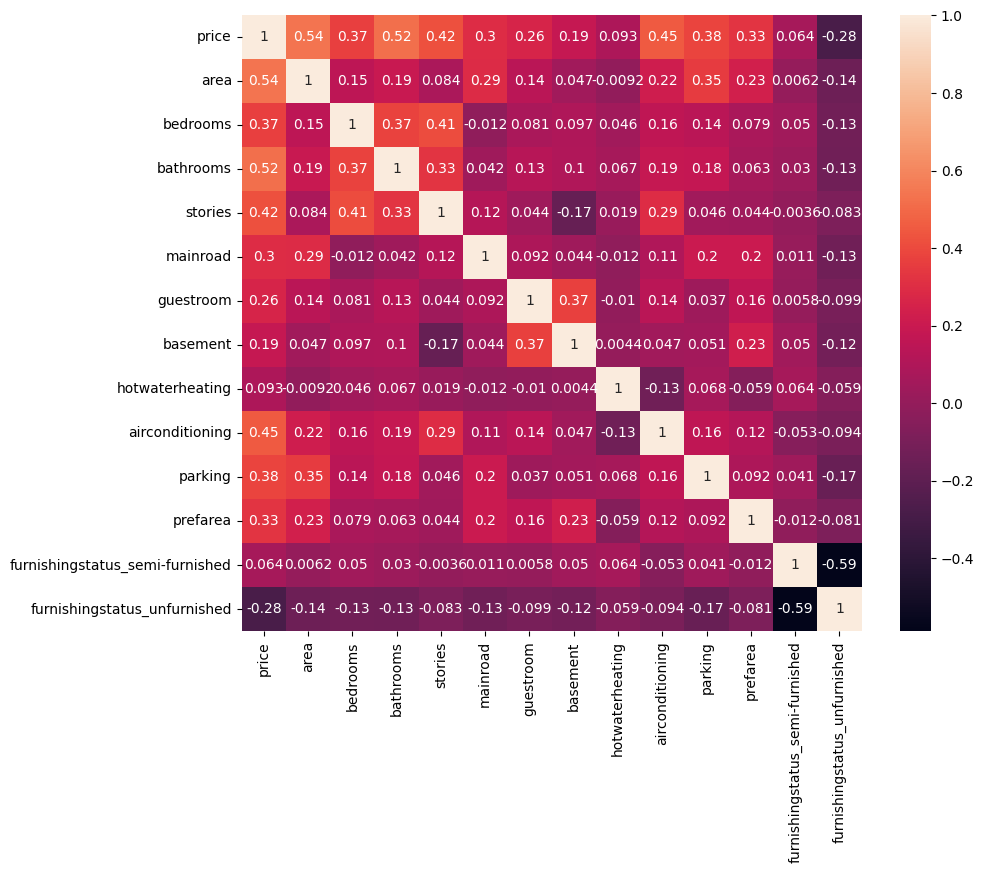

In [25]:
# 存在明显的共线性问题
plt.figure(figsize=(10, 8))
sns.heatmap(houseprice_clean.corr(), annot=True)
plt.show()

In [41]:
# 移除一个最大的不显著变量
X_1 = X.drop(['furnishingstatus_semi-furnished'], axis=1)
X_1

,const,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_unfurnished
0,1.0,7420,4,2,3,1,0,0,0,1,2,1,0
1,1.0,8960,4,4,4,1,0,0,0,1,3,0,0
2,1.0,9960,3,2,2,1,0,1,0,0,2,1,0
3,1.0,7500,4,2,2,1,0,1,0,1,3,1,0
4,1.0,7420,4,1,2,1,1,1,0,1,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1.0,3000,2,1,1,1,0,1,0,0,2,0,1
541,1.0,2400,3,1,1,0,0,0,0,0,0,0,0
542,1.0,3620,2,1,1,1,0,0,0,0,0,0,1
543,1.0,2910,3,1,1,0,0,0,0,0,0,0,0


In [35]:
result_1 = sm.OLS(y, X_1).fit()
result_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.675
Method:                 Least Squares   F-statistic:                     94.95
Date:                Mon, 09 Feb 2026   Prob (F-statistic):          9.85e-124
Time:                        10:43:07   Log-Likelihood:                -8331.6
No. Observations:                 545   AIC:                         1.669e+04
Df Residuals:                     532   BIC:                         1.675e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                         6741.9729   2.48e+05      0.027      0.978   -4.81e+05    4.94e+05
area                           244.4553     24.257     10.078      0.000     196.805     292.106
bedrooms                      1.144e+05   7.25e+04      1.578      0.115   -2.81e+04    2.57e+05
bathrooms                     9.885e+05   1.03e+05      9.573      0.000    7.86e+05    1.19e+06
stories                       4.514e+05   6.41e+04      7.041      0.000    3.25e+05    5.77e+05
mainroad                      4.237e+05   1.42e+05      2.984      0.003    1.45e+05    7.03e+05
guestroom                     3.022e+05   1.32e+05      2.298      0.022    4.38e+04    5.61e+05
basement                      3.501e+05    1.1e+05      3.177      0.002    1.34e+05    5.67e+05
hotwaterheating               8.536e+05   2.23e+05      3.829      0.000    4.16e+05    1.29e+06
airconditioning               8.689e+05   1.08e+05      8.059      0.000    6.57e+05    1.08e+06
parking                       2.778e+05   5.85e+04      4.752      0.000    1.63e+05    3.93e+05
prefarea                      6.531e+05   1.16e+05      5.653      0.000    4.26e+05     8.8e+05
furnishingstatus_unfurnished -3.812e+05   1.01e+05     -3.772      0.000    -5.8e+05   -1.83e+05
==============================================================================
Omnibus:                       98.444   Durbin-Watson:                   1.208
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              260.659
Skew:                           0.898   Prob(JB):                     2.50e-57
Kurtosis:                       5.873   Cond. No.                     3.23e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.23e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [42]:
# 再移除截距项（不显著）
X_2 = X_1.drop(['const'], axis=1)
X_2

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_unfurnished
0,7420,4,2,3,1,0,0,0,1,2,1,0
1,8960,4,4,4,1,0,0,0,1,3,0,0
2,9960,3,2,2,1,0,1,0,0,2,1,0
3,7500,4,2,2,1,0,1,0,1,3,1,0
4,7420,4,1,2,1,1,1,0,1,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,1,0,1,0,0,2,0,1
541,2400,3,1,1,0,0,0,0,0,0,0,0
542,3620,2,1,1,1,0,0,0,0,0,0,1
543,2910,3,1,1,0,0,0,0,0,0,0,0


In [38]:
result_2 = sm.OLS(y, X_2).fit()
result_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  price   R-squared (uncentered):                   0.958
Model:                            OLS   Adj. R-squared (uncentered):              0.957
Method:                 Least Squares   F-statistic:                              1003.
Date:                Mon, 09 Feb 2026   Prob (F-statistic):                        0.00
Time:                        10:43:45   Log-Likelihood:                         -8331.6
No. Observations:                 545   AIC:                                  1.669e+04
Df Residuals:                     533   BIC:                                  1.674e+04
Df Model:                          12                                                  
Covariance Type:            nonrobust                                                  
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
area                           244.6193     23.472     10.422      0.000     198.510     290.728
bedrooms                      1.156e+05   5.91e+04      1.957      0.051    -436.568    2.32e+05
bathrooms                      9.89e+05   1.01e+05      9.754      0.000     7.9e+05    1.19e+06
stories                       4.514e+05    6.4e+04      7.053      0.000    3.26e+05    5.77e+05
mainroad                      4.253e+05   1.28e+05      3.312      0.001    1.73e+05    6.78e+05
guestroom                      3.02e+05   1.31e+05      2.302      0.022    4.43e+04     5.6e+05
basement                      3.504e+05    1.1e+05      3.198      0.001    1.35e+05    5.66e+05
hotwaterheating               8.537e+05   2.23e+05      3.833      0.000    4.16e+05    1.29e+06
airconditioning               8.687e+05   1.07e+05      8.088      0.000    6.58e+05    1.08e+06
parking                       2.776e+05   5.81e+04      4.777      0.000    1.63e+05    3.92e+05
prefarea                      6.528e+05   1.15e+05      5.679      0.000    4.27e+05    8.79e+05
furnishingstatus_unfurnished -3.804e+05    9.6e+04     -3.962      0.000   -5.69e+05   -1.92e+05
==============================================================================
Omnibus:                       98.238   Durbin-Watson:                   1.209
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              259.922
Skew:                           0.897   Prob(JB):                     3.62e-57
Kurtosis:                       5.869   Cond. No.                     2.74e+04
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 2.74e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [43]:
# 再移除一个较不显著的变量：bedrooms
X_3 = X_2.drop(['bedrooms'], axis=1)
X_3

,area,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_unfurnished
0,7420,2,3,1,0,0,0,1,2,1,0
1,8960,4,4,1,0,0,0,1,3,0,0
2,9960,2,2,1,0,1,0,0,2,1,0
3,7500,2,2,1,0,1,0,1,3,1,0
4,7420,1,2,1,1,1,0,1,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...
540,3000,1,1,1,0,1,0,0,2,0,1
541,2400,1,1,0,0,0,0,0,0,0,0
542,3620,1,1,1,0,0,0,0,0,0,1
543,2910,1,1,0,0,0,0,0,0,0,0


In [44]:
result_3 = sm.OLS(y, X_3).fit()
result_3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  price   R-squared (uncentered):                   0.957
Model:                            OLS   Adj. R-squared (uncentered):              0.956
Method:                 Least Squares   F-statistic:                              1088.
Date:                Mon, 09 Feb 2026   Prob (F-statistic):                        0.00
Time:                        10:46:49   Log-Likelihood:                         -8333.5
No. Observations:                 545   AIC:                                  1.669e+04
Df Residuals:                     534   BIC:                                  1.674e+04
Df Model:                          11                                                  
Covariance Type:            nonrobust                                                  
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
area                           257.5854     22.577     11.409      0.000     213.234     301.936
bathrooms                     1.071e+06   9.27e+04     11.553      0.000    8.89e+05    1.25e+06
stories                       5.084e+05   5.71e+04      8.898      0.000    3.96e+05    6.21e+05
mainroad                      4.672e+05   1.27e+05      3.679      0.000    2.18e+05    7.17e+05
guestroom                     2.851e+05   1.31e+05      2.172      0.030    2.72e+04    5.43e+05
basement                      4.016e+05   1.07e+05      3.765      0.000    1.92e+05    6.11e+05
hotwaterheating               8.668e+05   2.23e+05      3.884      0.000    4.28e+05    1.31e+06
airconditioning               8.543e+05   1.07e+05      7.952      0.000    6.43e+05    1.07e+06
parking                       2.793e+05   5.83e+04      4.794      0.000    1.65e+05    3.94e+05
prefarea                      6.443e+05   1.15e+05      5.594      0.000    4.18e+05    8.71e+05
furnishingstatus_unfurnished -3.493e+05   9.49e+04     -3.679      0.000   -5.36e+05   -1.63e+05
==============================================================================
Omnibus:                       94.840   Durbin-Watson:                   1.262
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              251.889
Skew:                           0.865   Prob(JB):                     2.01e-55
Kurtosis:                       5.845   Cond. No.                     2.74e+04
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 2.74e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [45]:
# 此时所有变量都以显著，但仍有一个变量的p值与其他变量存在明显不同：guestroom，我们再尝试将它移除试试
X_4 = X_3.drop(['guestroom'], axis=1)
X_4

,area,bathrooms,stories,mainroad,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_unfurnished
0,7420,2,3,1,0,0,1,2,1,0
1,8960,4,4,1,0,0,1,3,0,0
2,9960,2,2,1,1,0,0,2,1,0
3,7500,2,2,1,1,0,1,3,1,0
4,7420,1,2,1,1,0,1,2,0,0
...,...,...,...,...,...,...,...,...,...,...
540,3000,1,1,1,1,0,0,2,0,1
541,2400,1,1,0,0,0,0,0,0,0
542,3620,1,1,1,0,0,0,0,0,1
543,2910,1,1,0,0,0,0,0,0,0


In [46]:
result_4 = sm.OLS(y, X_4).fit()
result_4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                  price   R-squared (uncentered):                   0.957
Model:                            OLS   Adj. R-squared (uncentered):              0.956
Method:                 Least Squares   F-statistic:                              1188.
Date:                Mon, 09 Feb 2026   Prob (F-statistic):                        0.00
Time:                        10:48:28   Log-Likelihood:                         -8335.9
No. Observations:                 545   AIC:                                  1.669e+04
Df Residuals:                     535   BIC:                                  1.673e+04
Df Model:                          10                                                  
Covariance Type:            nonrobust                                                  
================================================================================================
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
area                           260.5045     22.615     11.519      0.000     216.079     304.930
bathrooms                     1.073e+06    9.3e+04     11.535      0.000     8.9e+05    1.26e+06
stories                       5.123e+05   5.73e+04      8.939      0.000       4e+05    6.25e+05
mainroad                      4.666e+05   1.27e+05      3.662      0.000    2.16e+05    7.17e+05
basement                      4.799e+05   1.01e+05      4.763      0.000    2.82e+05    6.78e+05
hotwaterheating               8.653e+05   2.24e+05      3.864      0.000    4.25e+05    1.31e+06
airconditioning               8.738e+05   1.07e+05      8.133      0.000    6.63e+05    1.08e+06
parking                       2.739e+05   5.84e+04      4.689      0.000    1.59e+05    3.89e+05
prefarea                      6.566e+05   1.15e+05      5.688      0.000     4.3e+05    8.83e+05
furnishingstatus_unfurnished -3.619e+05   9.51e+04     -3.806      0.000   -5.49e+05   -1.75e+05
==============================================================================
Omnibus:                       93.190   Durbin-Watson:                   1.265
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              238.722
Skew:                           0.863   Prob(JB):                     1.45e-52
Kurtosis:                       5.744   Cond. No.                     2.74e+04
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 2.74e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

可以看到，将这个变量移除之后，实际的回归结果分析已不再产生明显的改善。

## 模型预测